# Customer Churn & Retention Analysis

In [342]:
# Import libraries for data analysis and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [343]:
# Load the dataset into a dataframe
df = pd.read_csv("telco_customer_churn.csv")

# View first 5 rows to understand structure
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [344]:
# Check structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [345]:
# Check summary statistics (only numeric columns)
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [346]:
# Check if any column has missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning

In [347]:
# Remove customer ID because it does not help prediction
df = df.drop(['customerID'], axis=1)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove missing values
df = df.dropna()

# Convert Churn into binary format
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [348]:
# Calculate percentage of customers who churned
df['Churn'].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

## Exploratory Data Analysis
This section explores churn patterns across contract type, tenure, and monthly charges.

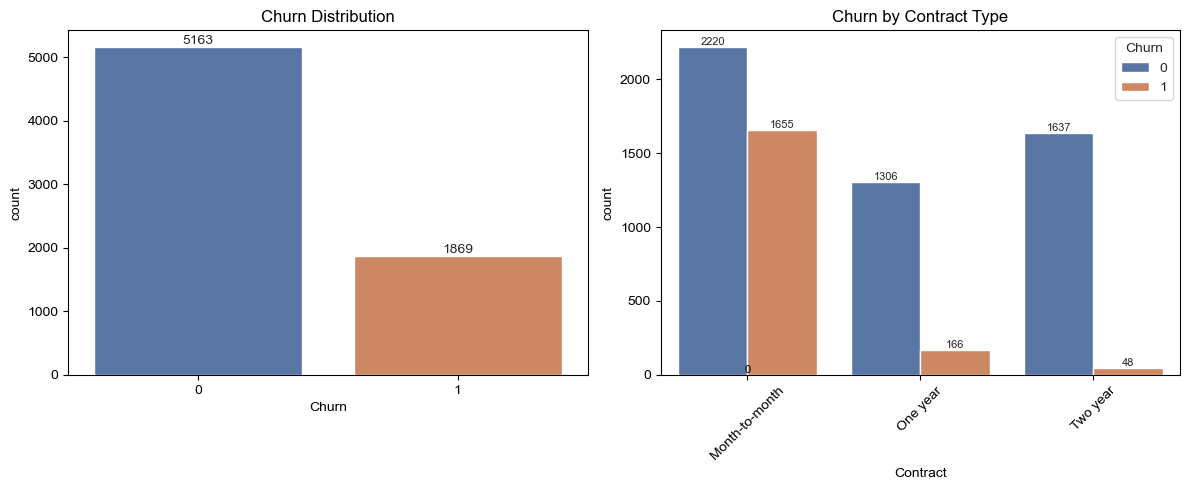

In [368]:
# Create side-by-side plots

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.set_style("whitegrid")
palette = {0: "#4C72B0", 1: "#DD8452"}

# Plot 1: Churn Distribution
sns.countplot(x='Churn', data=df, hue='Churn', palette=palette, ax=axes[0], legend=False)
axes[0].set_title("Churn Distribution")

# Adding numbers on top
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')

# Plot 2: Churn by Contract Type
sns.countplot(x='Contract', hue='Churn', data=df, palette=palette, ax=axes[1])
axes[1].set_title("Churn by Contract Type")
axes[1].tick_params(axis='x', rotation=45)

# Add numbers on top
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

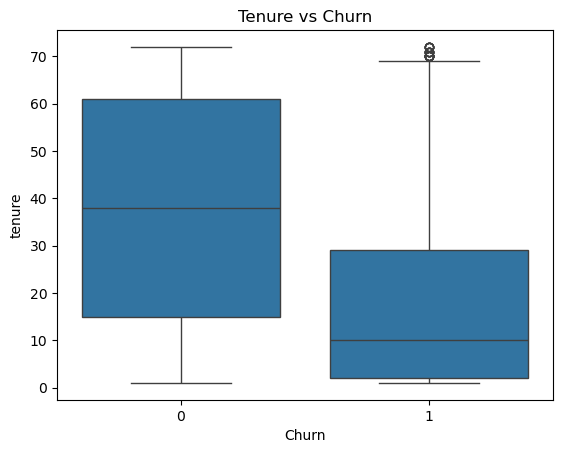

In [351]:
# Compare how long customers stay before churning

sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

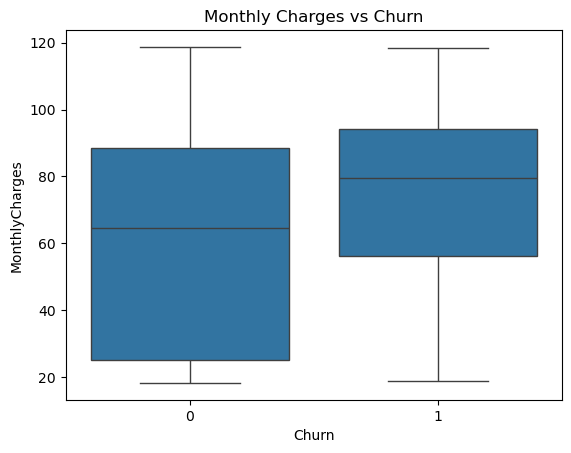

In [352]:
# Analyse impact of monthly charges on churn

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

## Model Building

In [353]:
# Convert categorical columns into numeric using one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Features (inputs)
X = df_encoded.drop('Churn', axis =1)

# Target (output)
y = df_encoded['Churn']

In [354]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [355]:
from sklearn.preprocessing import StandardScaler

# scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [356]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create model
log_model = LogisticRegression(max_iter=2000, class_weight='balanced')

# Train model
log_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7313432835820896
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



In [357]:
# Train a Random Forest model to compare with Logistic Regression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7860696517412935
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



## Model Comparison
Logistic Regression performed better in identifying churn customers, achieving a higher recall (~79%), which is critical for business use cases. 

Although Random Forest achieved higher overall accuracy (~78%), it struggled to correctly identify churn cases, making Logistic Regression more suitable for this problem.

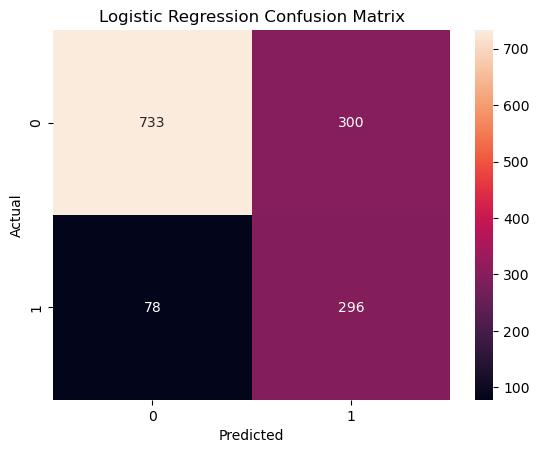

In [358]:
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

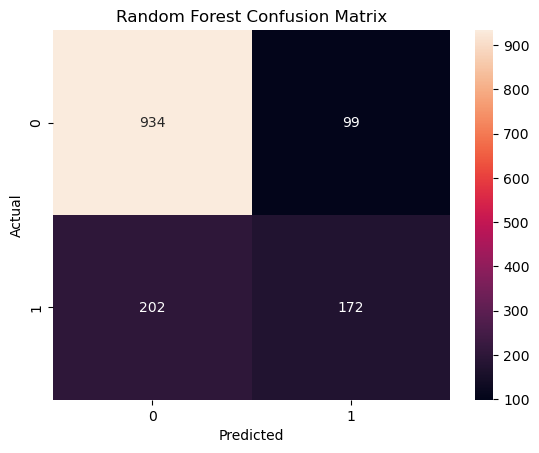

In [359]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

In [360]:
log_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

log_importance.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.733778
3,TotalCharges,0.657752
23,StreamingMovies_Yes,0.263129
21,StreamingTV_Yes,0.258066
9,MultipleLines_Yes,0.162098
28,PaymentMethod_Electronic check,0.139128
26,PaperlessBilling_Yes,0.120915
0,SeniorCitizen,0.095168
17,DeviceProtection_Yes,0.051283
5,Partner_Yes,0.020778


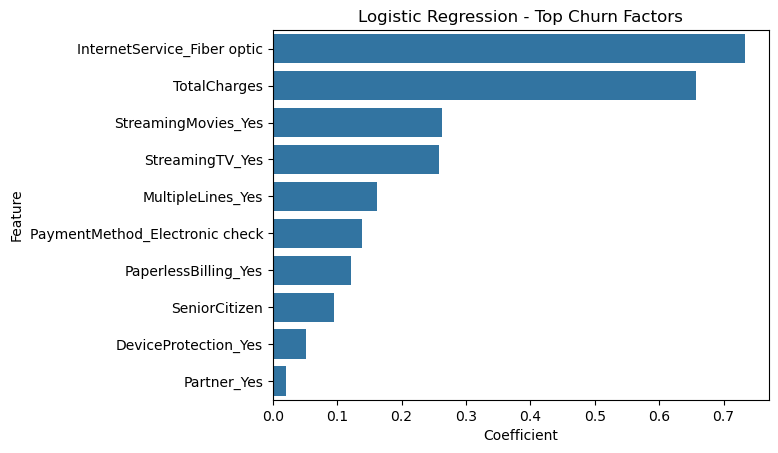

In [361]:
top_log_features = log_importance.head(10)

sns.barplot(x='Coefficient', y='Feature', data=top_log_features)
plt.title("Logistic Regression - Top Churn Factors")
plt.show()

In [362]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

rf_importance.head(10)

,Feature,Importance
3,TotalCharges,0.176046
1,tenure,0.166933
2,MonthlyCharges,0.153656
25,Contract_Two year,0.056603
10,InternetService_Fiber optic,0.040465
28,PaymentMethod_Electronic check,0.033883
24,Contract_One year,0.031462
13,OnlineSecurity_Yes,0.029007
4,gender_Male,0.025048
19,TechSupport_Yes,0.024035


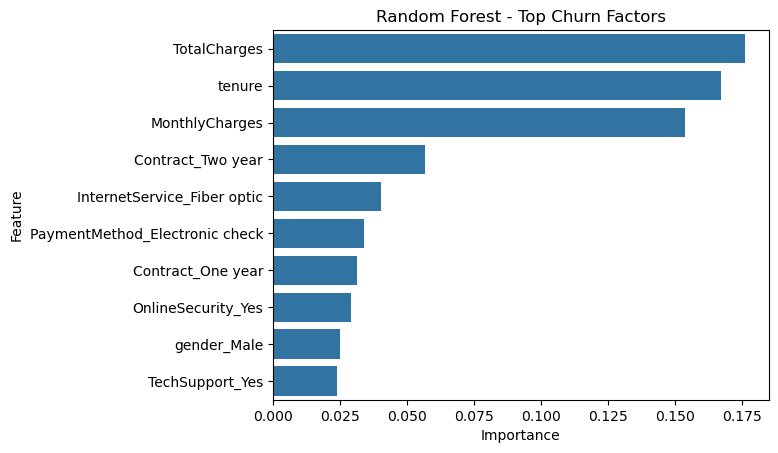

In [363]:
top_rf_features = rf_importance.head(10)

sns.barplot(x='Importance', y='Feature', data=top_rf_features)
plt.title("Random Forest - Top Churn Factors")
plt.show()

## Key Insights

- Around 26.6% of customers churned, indicating a moderate churn rate.
- Customers on month-to-month contracts showed the highest churn behaviour.
- Customers with shorter tenure were more likely to leave, suggesting early-stage churn risk.
- Higher monthly charges were associated with increased churn.
- Machine learning analysis revealed that fiber optic internet users and customers with higher total charges also had higher churn risk.
- Logistic Regression performed better for identifying churn customers, achieving strong recall (~79%), making it suitable for churn prediction.